# 自动驾驶全栈评测指标指南 (Autonomous Driving Metrics Guide)
**前言**

简述本指南的目的：带你从基础的机器学习概念出发，一步步理解自动驾驶四大核心模块（感知、预测、规控、端到端）的评测标准。

## 基石 —— 机器学习基础指标 (ML Fundamentals)

我们先从最基础的三个计数开始：

- **TP (True Positive)**：预测为正且真实为正（正确检出）
  - 集合表达：$TP = |GT \cap Pred|$
- **FP (False Positive)**：预测为正但真实为负（误检/鬼影）
  - 集合表达：$FP = |Pred - GT|$
    - 预测里有，但真值里没有，误检
- **FN (False Negative)**：预测为负但真实为正（漏检）
  - 集合表达：$FN = |GT - Pred|$
    - 真值里有，但预测里没有，漏检

在此基础上可定义常用指标：

- **Precision（精确率）**：预测为正的结果里，有多少是真的
  - $Precision = \frac{TP}{TP + FP}$
- **Recall（召回率）**：真实为正的目标里，有多少被找到了
  - $Recall = \frac{TP}{TP + FN}$
- **F1 Score**：Precision 与 Recall 的调和平均
  - $F1 = \frac{2 \cdot Precision \cdot Recall}{Precision + Recall}$
    - 如何理解F1-score呢，这个指标避免模型在单一指标上作弊，precision很高，模型只在确定时预测，导致recall很低，找到的目标太少，调和值让模型又准又全

In [6]:
import numpy as np

# 假设场景里真实有车的ID是 1和2
ground_truth = {1, 2}
# 模型预测出了车的ID是 1和3
predictions = {1, 3}

# 集合运算秒懂 TP/FP/FN
TP = len(ground_truth.intersection(predictions)) # 猜对了 (1) -> 1个
FP = len(predictions - ground_truth)             # 瞎猜的/鬼影 (3) -> 1个
FN = len(ground_truth - predictions)             # 没看到的/漏检 (2) -> 1个

precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

print("=== 基础计数（含义）===")
print(f"TP = {TP}：正确检出（预测有，且真实也有）")
print(f"FP = {FP}：误检/鬼影（预测有，但真实没有）")
print(f"FN = {FN}：漏检（预测没有，但真实有）")

print("\n=== 评测指标（含义）===")
print(f"Precision = {precision:.0%}：预测为正的结果里，有多少是真的")
print(f"Recall    = {recall:.0%}：真实为正的目标里，有多少被找到了")
print(f"F1 Score  = {f1_score:.0%}：综合平衡 Precision 与 Recall")

=== 基础计数（含义）===
TP = 1：正确检出（预测有，且真实也有）
FP = 1：误检/鬼影（预测有，但真实没有）
FN = 1：漏检（预测没有，但真实有）

=== 评测指标（含义）===
Precision = 50%：预测为正的结果里，有多少是真的
Recall    = 50%：真实为正的目标里，有多少被找到了
F1 Score  = 50%：综合平衡 Precision 与 Recall


通常在目标检测评测中，Ground Truth 和 Prediction 需要通过匹配算法（如 IoU Matching 或 Hungarian Matching）建立对应关系，然后再计算 TP、FP 和 FN。

在本示例中，我们假设 GT 和 Prediction 已经共享同一 ID，因此可以通过集合运算直接进行“自然匹配”（Natural Matching）来计算 TP、FP 和 FN。

### PR Curve、AP 与 mAP

#### 1) PR Curve（Precision–Recall Curve）
在不同置信度阈值下，观察 Precision 与 Recall 的变化关系。

- 阈值高：只保留高置信度预测，通常 **Precision 高、Recall 低**
- 阈值低：保留更多预测，通常 **Recall 高、Precision 低**

PR Curve 用于查看模型在“更严格”到“更宽松”条件下的整体表现。

#### 2) AP（Average Precision）
AP 是 PR 曲线下的面积（AUC），可理解为对该类别在不同召回率上的综合性能评分。

$$
AP = \int_0^1 P(R)\,dR
$$

- AP 越高，说明该类别检测性能越好
- AP = 1 表示理想状态，AP = 0 表示几乎无有效检测

#### 3) mAP（mean Average Precision）
mAP 是多类别任务中各类别 AP 的平均值，用于衡量整体检测能力。

$$
mAP = \frac{1}{C}\sum_{c=1}^{C} AP_c
$$

其中 $C$ 为类别数。实践中常见两种口径：

- **mAP@0.5**：在 IoU 阈值 0.5 下计算
- **mAP@[0.5:0.95]**：在多个 IoU 阈值（步长 0.05）下平均，更严格（COCO 常用）

In [8]:
import numpy as np

def compute_pr_ap(tp_flags, num_gt):
    tp_flags = np.array(tp_flags, dtype=int)
    fp_flags = 1 - tp_flags

    cum_tp = np.cumsum(tp_flags)
    cum_fp = np.cumsum(fp_flags)

    precision = cum_tp / (cum_tp + cum_fp + 1e-12)
    recall = cum_tp / (num_gt + 1e-12)

    # AP: 使用 precision-recall 包络线做离散积分（常见做法）
    mrec = np.concatenate(([0.0], recall, [1.0]))
    mpre = np.concatenate(([0.0], precision, [0.0]))
    for i in range(len(mpre) - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])
    ap = np.sum((mrec[1:] - mrec[:-1]) * mpre[1:])

    return precision, recall, ap

# ===== 单类别示例（计算 PR 与 AP） =====
# 含义：预测框按置信度从高到低排序后，1 表示 TP，0 表示 FP
tp_flags_car = [1, 1, 0, 1, 0]
num_gt_car = 4

precision_car, recall_car, ap_car = compute_pr_ap(tp_flags_car, num_gt_car)

print("=== 单类别: car ===")
print("排序后 TP 标记:", tp_flags_car)
print("Precision 序列:", np.round(precision_car, 3))
print("Recall 序列   :", np.round(recall_car, 3))
print(f"AP(car) = {ap_car:.3f}")
print("解释：AP 越高，说明该类别在不同阈值下总体 Precision-Recall 权衡越好。")

# ===== 多类别示例（计算 mAP） =====
tp_flags_ped = [1, 0, 1, 0]
num_gt_ped = 3

_, _, ap_ped = compute_pr_ap(tp_flags_ped, num_gt_ped)

map_2cls = np.mean([ap_car, ap_ped])

print("\n=== 多类别: car + pedestrian ===")
print(f"AP(car)        = {ap_car:.3f}")
print(f"AP(pedestrian) = {ap_ped:.3f}")
print(f"mAP            = {map_2cls:.3f}")
print("解释：mAP 是各类别 AP 的平均值，反映整体检测能力。")

=== 单类别: car ===
排序后 TP 标记: [1, 1, 0, 1, 0]
Precision 序列: [1.    1.    0.667 0.75  0.6  ]
Recall 序列   : [0.25 0.5  0.5  0.75 0.75]
AP(car) = 0.687
解释：AP 越高，说明该类别在不同阈值下总体 Precision-Recall 权衡越好。

=== 多类别: car + pedestrian ===
AP(car)        = 0.687
AP(pedestrian) = 0.556
mAP            = 0.622
解释：mAP 是各类别 AP 的平均值，反映整体检测能力。


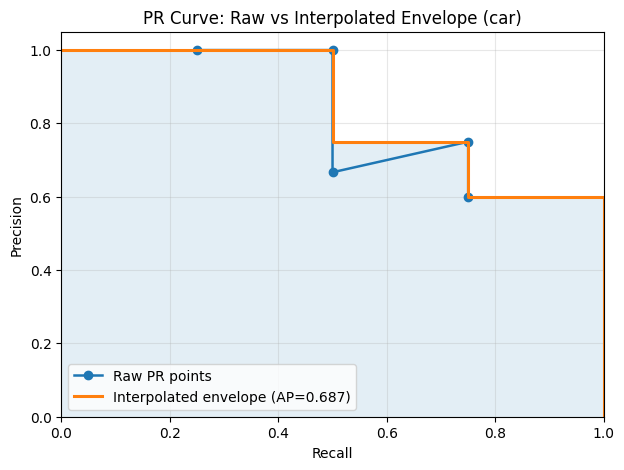

说明1：蓝点线是原始 PR 采样点。
说明2：阶梯线是 AP 计算使用的插值包络线（单调不增）。
说明3：阴影面积对应 AP，当前 AP(car) = 0.687。


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 第6个单元已计算得到 recall_car / precision_car / ap_car
# 这里复现 AP 计算中的插值包络线（与 compute_pr_ap 口径一致）
mrec = np.concatenate(([0.0], recall_car, [1.0]))
mpre = np.concatenate(([0.0], precision_car, [0.0]))
for i in range(len(mpre) - 1, 0, -1):
    mpre[i - 1] = max(mpre[i - 1], mpre[i])

plt.figure(figsize=(7, 5))

# 原始 PR 点线（按置信度阈值变化得到）
plt.plot(
    recall_car,
    precision_car,
    marker='o',
    linewidth=1.8,
    label='Raw PR points'
 )

# 插值包络线（AP 积分使用）
plt.step(
    mrec,
    mpre,
    where='post',
    linewidth=2.2,
    label=f'Interpolated envelope (AP={ap_car:.3f})'
 )

# AP 面积可视化
plt.fill_between(mrec, mpre, step='post', alpha=0.12)

plt.xlim(0, 1.0)
plt.ylim(0, 1.05)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve: Raw vs Interpolated Envelope (car)')
plt.grid(alpha=0.3)
plt.legend(loc='lower left')
plt.show()

print('说明1：蓝点线是原始 PR 采样点。')
print('说明2：阶梯线是 AP 计算使用的插值包络线（单调不增）。')
print(f'说明3：阴影面积对应 AP，当前 AP(car) = {ap_car:.3f}。')